# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

## Plan de solución

**Para entender la estructura del DataFrame, primero se importa la librería necesaria y se define la variable con la ruta de los archivos. Posteriormente se utilizan los métodos `.head()` e `.info()`, para visualizar las primeras filas del dataset y obtener la información general sobre el tipo de separadores, los nombres de las columnas, los valores nulos y los tipos de datos de cada columna; después de esta visualización inicial a los datos, se harán las modificaciones necesarias para preparar los datos para su análisis.**

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
# leer conjuntos de datos en los DataFrames
instacart_orders = pd.read_csv("../data/instacart_orders.csv", sep=';')

products= pd.read_csv("../data/products.csv", sep=';')

order_products = pd.read_csv("../data/order_products.csv", sep=';')

aisles = pd.read_csv("../data/aisles.csv", sep=';')

departments = pd.read_csv("../data/departments.csv", sep=';')

In [3]:
# mostrar información del DataFrame
print(instacart_orders.head())
print()
instacart_orders.info()

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-nu

In [4]:
# mostrar información del DataFrame
print(products.head())
products.info()

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
# mostrar información del DataFrame
print(order_products.head())
print()
order_products.info(show_counts=True)

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [6]:
# mostrar información del DataFrame
print(aisles.head())
print()
aisles.info()

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [7]:
# mostrar información del DataFrame
print(departments.head())
print()
departments.info()

   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


## Conclusiones

**Durante esta inspección inicial, observamos que el separador no era el predeterminado, por lo que fue necesario agregar el parámetro `sep=';'` al momento de leer el archivo para interpretar correctamente los datos. Al aplicar el método `info()` se detectaron valores nulos en algunas columnas de tres datasets. En el siguiente paso, se procederá con la limpieza de datos donde se eliminarán los duplicados y se procesarán los valores ausentes.**

# Paso 2. Preprocesamiento de los datos

## Plan de solución

**Para el preprocesamiento de los datos, se emplearán varios métodos como `isna(), fillna(), value_counts(), astype() y drop_duplicates()` con el objetivo de identificar y completar los valores ausentes, corregir los tipos de datos e identificar y eliminar los valores duplicados. Estos pasos garantizarán que los datos tengan un formato limpio y estructurado, adecuado para su análisis.**

### `instacart_orders` data frame

In [ ]:
# Revisar si hay pedidos duplicados
print(instacart_orders.value_counts())

order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
1021560   53767    3             3          2                  9.0                       2
467134    63189    21            3          2                  2.0                       2
391768    57671    19            3          2                  10.0                      2
2282673   86751    49            3          2                  2.0                       2
408114    68324    4             3          2                  18.0                      2
                                                                                        ..
1141863   88987    2             1          11                 14.0                      1
1141854   125458   91            6          8                  2.0                       1
1141847   156072   4             2          21                 6.0                       1
1141845   153218   2             3          8                  6.0                       1
3421

**Al llamar a `value_counts()` se puede observar que sí hay filas duplicadas y que tienen en común el día y la hora en la que se solicitaron las órdenes. Esto podría sugerir un patrón de error para ese día y esa hora.**

In [ ]:
# Verificar todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
wednesday_orders = instacart_orders[(instacart_orders['order_dow']== 3) & (instacart_orders['order_hour_of_day']==2)]
print(wednesday_orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

**El resultado sugiere que hay 121 filas donde se realizó una orden el miércoles a las 2 am, lo cual coincide con el patrón observado en las filas duplicadas. Esto podría indicar la presencia de errores en la recolección de datos especificamente en ese horario y día.**

In [10]:
# Contar cuantos duplicados hay hasta el momento
print(instacart_orders.duplicated().sum()) 

# Elimina los pedidos duplicados
instacart_orders.drop_duplicates(inplace=True)

15


In [ ]:
# verificar si hay filas duplicadas
print(instacart_orders.duplicated().sum())

0


In [ ]:
# verificar únicamente si hay IDs duplicados de pedidos
print(instacart_orders['order_id'].duplicated().sum())

0



**Durante el análisis se detectaron 15 filas completamente duplicadas. Para corregirlo, se utilizó el método `drop_duplicates(inplace=True)` y después se verificó que se hayan eliminado correctamente con el método `.duplicated().sum()`. Además, se revisó también la columna de `order_id` para asegurarse de que no se repitiera ninguna orden. Con estos pasos de limpieza se concluye el tratamiento de datos duplicados y ahora se puede continuar con el procesamiento de valores nulos para este dataset.**

### `products` data frame

In [56]:
# Verifica si hay filas totalmente duplicadas
products.value_counts()

product_id  product_name                                      aisle_id  department_id
1           CHOCOLATE SANDWICH COOKIES                        61        19               1
33146       REVOLT KILLER CITRUS                              64        7                1
33124       HEALTHY KIDS ORGANIC CHOCOLATE NUTRITIONAL SHAKE  92        18               1
33125       ORGANIC MINI CHEDDAR CHEESE CRACKERS              78        19               1
33126       SESAME FLATBREAD                                  112       3                1
                                                                                        ..
16568       DISHWASHER DETERGENT                              74        17               1
16569       HUMMUS ORIGINAL                                   67        20               1
16570       ORGANIC FRESH CARROT CHIPS                        123       4                1
16571       UNBLEACHED JUMBO BAKING CUPS                      97        13               1
4969

In [54]:
# Revisa únicamente si hay ID de productos duplicados
products['product_id'].duplicated().sum()

0

In [64]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products['product_name']= products['product_name'].str.upper()

In [65]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_faltantes = products[(~products['product_name'].isna()) & products['product_name'].duplicated()]
print(productos_faltantes['product_name'].unique()[:10])

['UNKNOWN' 'BIOTIN 1000 MCG' 'GREEN TEA WITH GINSENG AND HONEY'
 'CREAM OF MUSHROOM SOUP' 'CINNAMON ROLLS WITH ICING'
 'AMERICAN CHEESE SLICES' 'CAULIFLOWER HEAD' 'PUMPKIN SPICE'
 'HEARTS OF PALM' 'CREAM OF TARTAR']



**Al usar el método `value_counts()` se observó que no hay filas duplicadas. Para explorar los datos de la columna `product_name`, se utilizó el método `str.upper()` para unificar a mayúsculas el nombre de los productos y facilitar la comparación. Después, con el método `value_counts()` se identificó que sí hay nombres repetidos, lo cual no afecta el análisis, ya que distintos usuarios pueden solicitar el mismo producto.**

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
departments.value_counts().sort_index()

department_id  department     
1              frozen             1
2              other              1
3              bakery             1
4              produce            1
5              alcohol            1
6              international      1
7              beverages          1
8              pets               1
9              dry goods pasta    1
10             bulk               1
11             personal care      1
12             meat seafood       1
13             pantry             1
14             breakfast          1
15             canned goods       1
16             dairy eggs         1
17             household          1
18             babies             1
19             snacks             1
20             deli               1
21             missing            1
dtype: int64

In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
departments['department_id'].duplicated().sum()

0



**Primero se utilizó el método `value_counts()` para identificar filas completamente duplicadas. Al comprobar que no había duplicados, se realizó una segunda verificación a la columna `department_id` con el método `.duplicated().sum()` donde también se confirmó que no existen duplicados en este dataset.**

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
aisles.value_counts().sort_index()

aisle_id  aisle                     
1         prepared soups salads         1
2         specialty cheeses             1
3         energy granola bars           1
4         instant foods                 1
5         marinades meat preparation    1
                                       ..
130       hot cereal pancake mixes      1
131       dry pasta                     1
132       beauty                        1
133       muscles joints pain relief    1
134       specialty wines champagnes    1
Length: 134, dtype: int64

In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisles['aisle_id'].duplicated().sum()

0



**Al igual que el dataset de `departments`, primero se utilizó el método `value_counts()` para identificar filas duplicadas. Tras verificar que no las hay, se hizo una segunda verificación sobre la columna `aisle_id`, donde los resultados confirmaron que tampoco existen duplicados en este dataset.**

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
order_products.value_counts()

order_id  product_id  add_to_cart_order  reordered
4         10054       5.0                1            1
2277733   35233       5.0                1            1
2277734   15233       4.0                1            1
          11471       2.0                1            1
          6374        3.0                1            1
                                                     ..
1145037   26790       21.0               1            1
          27767       10.0               1            1
          32086       16.0               0            1
          33572       5.0                1            1
3421079   30136       1.0                0            1
Length: 4544171, dtype: int64

In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_products[['order_id', 'product_id']].value_counts()

order_id  product_id
4         10054         1
2277640   5250          1
          44238         1
          39450         1
          26629         1
                       ..
1144978   43789         1
          45582         1
1144992   5450          1
          16797         1
3421079   30136         1
Length: 4545007, dtype: int64


**Se puede observar que al utilizar el método `value_counts()`, no se encontraron filas completamente duplicadas. Sin embargo, sí hay elementos repetidos en las columnas `'order_id' y product_id`, lo cual es normal, ya que un pedido puede contener múltiples productos y los mismos productos pueden aparecer en distintos pedidos. Para confirmar que no existen filas idénticas, se utilizó de nuevo el método `value_counts()` especificando una lista con las columnas `order_id y product_id`, lo que permitió verificar que cada combinación de producto dentro de una orden es única.**

## Eliminar los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'

products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21



**Al aplicar el filtro con el método `.isna()`, se observó que hay 1258 filas con valores ausentes en la columna `product_name` que corresponden todos al pasillo 100 del departamento 21. Este patrón sugiere que podría haber un problema en la captura de nombres para ese pasillo y departamento en particular o, alternativamente corresponder a artículos temporales que no han sido clasificados en el sistema, como productos estacionales o de edición limitada.**


In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
aisle_100 = products[products['aisle_id']==100]
print(aisle_100)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]




**Al utilizar el filtro con la condición de que la columna `aisle_id` sea igual a 100, se puede confirmar que todos los valores ausentes en la columna `product_name` están relacionados con este pasillo, ya que también coincide el número de filas con la verificacion anterior. Esto respalda la hipótesis de que existe una inconsistencia con la captura de datos correspondiente al pasillo 100.**

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
dept_21 = products[products['department_id']==21]
print(dept_21)

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]



**Una vez más se comprueba la hipótesis de que los productos con valores ausentes están relacionados con el departamento 21 y el pasillo 100, ya que el número de filas sigue siendo el mismo después de aplicar el filtro donde la columna `department_id` es igual a 21. Esto confirma que los valores ausentes corresponden únicamente a esa combinación específica de pasillo y departamento.**

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.

print(departments[departments['department_id'] == 21])
print(aisles[aisles['aisle_id']==100])

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing



**Al filtrar las tablas `departments` con ID 21 y `aisles` con ID 100, se observó que ambos están etiquetados como 'missing'. Esto confirma que no hay información clara que describa el nombre del pasillo ni el departamento al que pertenecen los productos con valores ausentes, lo que refuerza la posibilidad de un problema en la captura de estos datos o que se trate de productos de ediciones temporales.**

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'].fillna('Unknown', inplace=True)

# Verificar que ya no hay valores ausentes
print(products[products['product_name'].isna()].count())

print()

# Verificar que se hayan reemplzado correctamente los valores ausentes por "Unknown" y que coincida el número de filas donde había valores ausentes (1258 filas)
print(products[products['product_name'] == 'Unknown'])

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

       product_id product_name  aisle_id  department_id
37             38      Unknown       100             21
71             72      Unknown       100             21
109           110      Unknown       100             21
296           297      Unknown       100             21
416           417      Unknown       100             21
...           ...          ...       ...            ...
49552       49553      Unknown       100             21
49574       49575      Unknown       100             21
49640       49641      Unknown       100             21
49663       49664      Unknown       100             21
49668       49669      Unknown       100             21

[1258 rows x 4 columns]



**Para eliminar los valores ausentes y que no interfirieran en el análisis de datos, se utilizó el método `fillna()` para reemplazar los valores `NaN` por el string `'Unknown'`. Posteriormente, se verificó mediante dos métodos: primero con el método `isna().count()` para asegurar que los valores ausentes fueron eliminados, y luego con un filtro que comprueba que el número de filas que originalmente marcaban valores ausentes coincide con las filas que ahora tienen "Unknown" como nombre del producto.**

### `orders` data frame

In [28]:
# Encuentra los valores ausentes

instacart_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
instacart_orders[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day']].isna().sum()

order_id             0
user_id              0
order_number         0
order_dow            0
order_hour_of_day    0
dtype: int64


**Primero, para verificar los valores ausentes en todas las columnas, se utilizó el método `.isna().sum()`, el cual reflejó que únicamente hay valores nulos en la columna `days_since_prior_order`. Posteriormente, para confirmar que en las demás columnas no había datos faltantes, se aplicó un filtro que excluye la columna `days_since_prior_order`. Se observó que sólo la columna `days_since_prior_order` contiene valores ausentes. Debido a que la columna `days_since_prior_order` representa el número de días desde el pedido anterior, este patrón podría indicar que los valores ausentes corresponden al primer pedido del cliente, y no existe un valor para calcular ese dato.**

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes

order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("Valor mínimo:", order_products['add_to_cart_order'].min())
print()
print('Valor máximo:', order_products['add_to_cart_order'].max())

Valor mínimo: 1.0

Valor máximo: 64.0


**Se puede observar que únicamente en la columna `add_to_cart_order` hay valores ausentes. Posteriormente, debido a que la columna `add_to_cart_order` muestra el orden secuencial en que se agregaron productos, se utilizó el método `.min() y .max()` para saber el número mínimo y máximo de productos en una orden.**

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

id_order_isna = order_products[order_products['add_to_cart_order'].isna()]['order_id'].sort_index()

print(id_order_isna)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

print(order_products[order_products['add_to_cart_order'].isna()].groupby('order_id')['product_id'].sum().min())

810



**Se asignó una nueva variable llamada `id_order_isna`, que almacena las IDs de órdenes con valores ausentes en la columna `add_to_cart_order`, aplicando el método `isna()['order_id']`. Posteriormente, se agruparon estas órdenes por la columna `order_id` y se contó el número de productos (`product_id`) en cada pedido para verificar cuantos productos incluía cada uno. El resultado muestra que el valor mínimo de productos en estas órdenes es de 810,  una cantidad atípicamente alta, lo cual podría indicar un error en la captura de datos al registrarse tantos productos en una sola orden.**


In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 
order_products['add_to_cart_order'].fillna('999', inplace=True)

# Convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

print()
order_products.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int64
 3   reordered          4545007 non-null  int64
dtypes: int64(4)
memory usage: 138.7 MB



**Se reemplazaron los datos ausentes por el número '999' usando el método `fillna()` como una forma de normalizar los datos con cifras muy altas. Posteriormente, se aplicó el método `'astype(int)'` para convertir el tipo de dato la columna de `'float64'` a `'int64'`. Finalmente, para verificar que no quedaron datos ausentes y que la conversión de tipo de la columna se realizó correctamente, se llama al método `info()`**

## Conclusiones

**Para la limpieza de los datos, primero se procesaron los valores duplicados en cada DataFrame. Se observó que únicamente `instacart_orders` contenía filas duplicadas: se detectaron 15 filas completamente idénticas, todas correspondientes a pedidos realizados a las 2 a.m. del miércoles, lo que sugiere un posible error en la captura de datos en ese horario. Estos duplicados fueron eliminados mediante el método `drop_duplicates()`.**

**Posteriormente, se realizó la búsqueda de valores ausentes en las tablas proporcionadas y se identificó que tres DataFrames contenían valores nulos en distintas columnas:**

**- `products`: Se detectaron 1258 filas con valores ausentes en la columna `product_name`, todas relacionadas con el pasillo 100 y el departamento 21. Al revisar las tablas `departments` y `aisles`, se observó que ambos están etiquetados como `'missing'`, lo que sugiere dos posibles explicaciones: una falla en la categorización de estos productos y/o que se trate de productos estacionales o de edición limitada que no han sido correctamente capturados en el sistema. Para resolverlo, los valores ausentes fueron reemplazados con la cadena `'Unknown'` mediante el método `fillna()`, permitiendo continuar con el análisis sin afectar la estructura del dataset.**

**- `instacart_orders`: Esta tabla presenta valores ausentes en la columna `days_since_prior_order`, lo cual es esperable, ya que representa los días desde el pedido anterior, y no aplica para los primeros pedidos de cada usuario. Estos valores se conservaron sin modificar.**

**- `order_products`: Se encontraron valores ausentes en la columna `add_to_cart_order`, que indica el orden en que los productos fueron añadidos al carrito. Se observó que las órdenes con valores ausentes en esta columna contenían un número atípicamente alto de productos (mínimo de 810), lo que sugiere posibles errores en la captura de datos. Para normalizar estas observaciones, se reemplazaron los valores ausentes por el número 999 utilizando `fillna()`, y posteriormente se transformó la columna de tipo `float64` a `int64` mediante `astype()`.**

**Después de este proceso de limpieza, en el que se identificaron, razonaron y trataron los valores duplicados, ausentes y los tipos de datos inconsistentes, el conjunto de datos quedó preparado para continuar con el análisis, libre de interferencias que pudieran afectar su claridad o confiabilidad.**


# Paso 3. Análisis de los datos



# [A]
1. Verificar que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crear un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crear un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crear un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
#Verificar los valores sensibles:
print("Hora mínima:", instacart_orders['order_hour_of_day'].min())
print("Hora máxima:", instacart_orders['order_hour_of_day'].max())
print("Día mínimo:", instacart_orders['order_dow'].min())
print("Día máximo:", instacart_orders['order_dow'].max())


Hora mínima: 0
Hora máxima: 23
Día mínimo: 0
Día máximo: 6


**Se imprimieron los valores mínimos y máximos de las columnas `order_hour_of_day` y `order_dow` para confirmar que las horas estén dentro del rango de de 0 a 23 y los días de la semana estén representados del 0 (domingo) al 6 (sábado), lo cual sugiere que los datos son consistentes y las columnas no presentan irregularidades.**

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

order_hour_of_day
0      2991
1      1671
2       958
3       744
4       735
5      1281
6      3757
7     10993
8     20268
9     28112
10    32195
11    32660
12    31754
13    32433
14    32797
15    32894
16    31579
17    26825
18    21795
19    17026
20    12891
21     9806
22     7670
23     5167
Name: user_id, dtype: int64



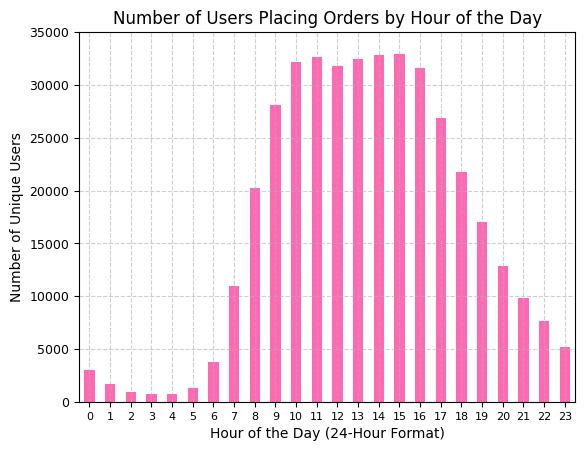

In [ ]:

# Pedidos por hora
pedidos_por_hora = instacart_orders.groupby('order_hour_of_day')['user_id'].nunique()
print(pedidos_por_hora)
print()

# Gráfica de órdenes de usuarios únicos por hora del día:
pedidos_por_hora.plot(kind='bar', xlabel='Hour of the Day (24-Hour Format)', ylabel='Number of Unique Users', title="Number of Users Placing Orders by Hour of the Day", xlim=[0,24], ylim=[0,35000], rot=0, color='hotpink')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.xticks(fontsize=8)
plt.yticks(fontsize=9)
plt.show()


**Al agrupar las órdenes por hora del día y contar los usuarios unicos que realizaron pedidos mediante `.groupby()` y `.plot()` se generó una gráfica que permite identificar los horarios con mayor actividad. Se observa que la mayor concentración de usuarios haciendo pedidos ocurre entre las 10:00 y 16:00 hrs, alcanzando su punto máximo a las 15:00 hrs con un total de 32,894 usuarios. Este comportamiento sugiere que muchos usuarios realizan sus compras en los momentos previos a la hora de la comida o cena, lo que refleja una tendencia a organizar sus compras antes de las comidas principales del día. Esta información podría aprovecharse para diseñar estrategias logísticas, tales como promociones u horarios y costos de entrega preferenciales en función de la demanda.**

### [A3] ¿Qué día de la semana compran víveres las personas?

Sunday       57661
Monday       56479
Tuesday      48587
Wednesday    45331
Thursday     44281
Friday       46127
Saturday     45604
Name: user_id, dtype: int64



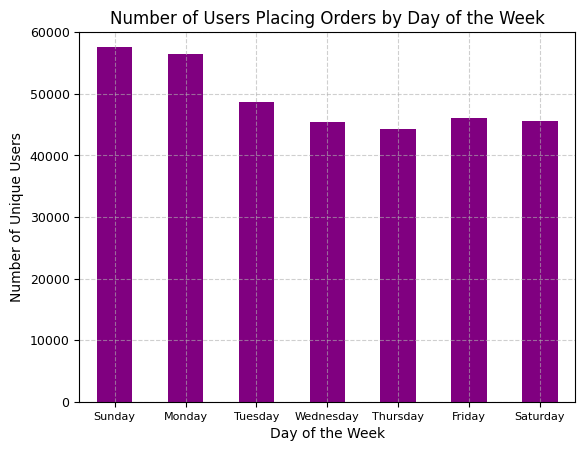

In [37]:
# Pedidos por día de la semana
días= ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
pedidos_por_día = instacart_orders.groupby('order_dow')['user_id'].nunique()
pedidos_por_día.index= días
print(pedidos_por_día)
print()

# Gráfica de días de la semana donde la gente hace sus compras
pedidos_por_día.plot(kind='bar', xlabel='Day of the Week', ylabel='Number of Unique Users', title="Number of Users Placing Orders by Day of the Week", ylim=[0,60000], rot=0, color='purple')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.xticks(fontsize=8)
plt.yticks(fontsize=9)
plt.show()


**Para este análisis, se agruparon los pedidos por días de la semana y se contó el número de usuarios únicos que realizan órdenes cada día mediante `groupby()` y `plot()`. Para facilitar la lectura de datos, se reemplazaron los códigos numéricos de 0  a 6 por los nombres de los días de la semana. La gráfica nos muestra un claro pico de actividad los domingos y los lunes, este comportamiento podría indicar que son los días preferidos por los usuarios para hacer compras, posiblemente aprovechando el inicio de semana para reabastecerse sin necesidad de acudir físicamente al supermercado. Esta información puede traducirse en una oportunidad de mejora, aplicando estrategias de marketing para incentivar las compras en los días de menor demanda para equilibrar las ventas a lo largo de la semana.**

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Mínimo de días de espera: 0.0
Máximo de días de espera: 30.0



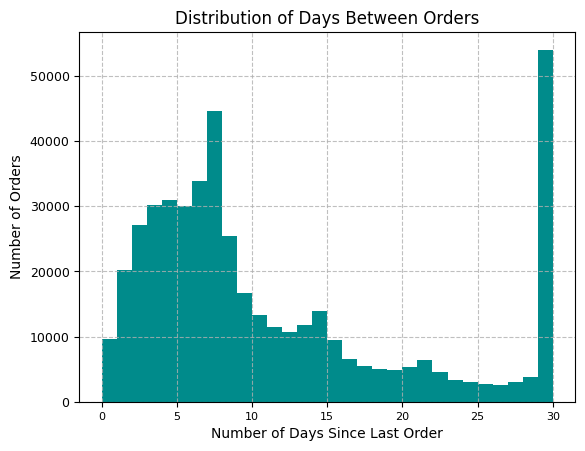

In [38]:
# Valores mínimo y máximo de días de espera
volver_a_comprar = instacart_orders['days_since_prior_order'].dropna()
print("Mínimo de días de espera:", volver_a_comprar.min())
print("Máximo de días de espera:", volver_a_comprar.max())
print()

# Gráfica de días que la gente espera para volver a hacer sus compras
volver_a_comprar.plot(kind='hist', bins=30, title='Distribution of Days Between Orders', color='darkcyan', rot=0)
plt.xlabel('Number of Days Since Last Order')
plt.ylabel("Number of Orders")
plt.grid(axis='both', linestyle='--', alpha=0.8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=9)
plt.show()


**En este análisis, se utiliza un histograma para visualizar los días de espera entre pedidos, así como identificar y los días mínimos y máximos mediante `min(), max() y plot()`. La gráfica muestra que la mayoría de los pedidos se realizan tras una espera de 30 días, seguido de un segundo pico importante a los 7 días, y dos menores a los 14 y 21 días. Esto sugiere que existen dos patrones principales de comportamiento: usuarios que compran mensualmente y usuarios que realizan pedidos semanales, así como un patrón secundario de compras quincenales o esporádicas. 
Este comportamiento respalda la hipótesis de que los usuarios utilizan la plataforma como un medio regular de reabastecimiento, especialmente a inicios de semana, evitando así visitas físicas al supermercado. Esta información puede ser útil para implementar estrategias de logística y marketing, por ejemplo, enfocadas a inicios de mes.**

# [B]  
1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?


### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

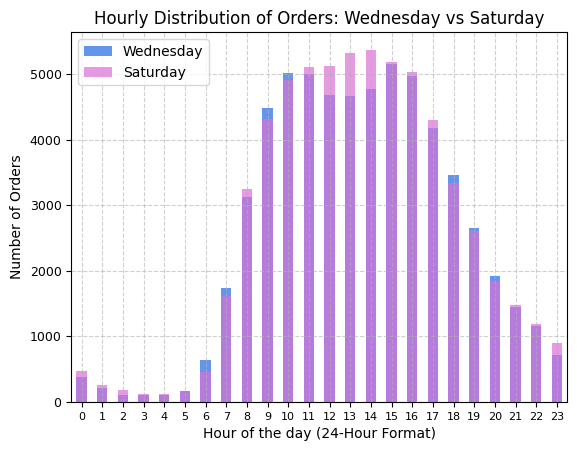

In [39]:
# Filtrar las órdenes de miércoles y sábado
wednesday = instacart_orders[instacart_orders['order_dow']== 3]
saturday = instacart_orders[instacart_orders['order_dow']== 6]

# Contar los pedidos por hora para cada día
wednesday_counts = wednesday['order_hour_of_day'].value_counts().sort_index()
saturday_counts = saturday['order_hour_of_day'].value_counts().sort_index()

# Graficar
wednesday_counts.plot(kind='bar', color='cornflowerblue')
saturday_counts.plot(kind='bar', alpha=.7, color='orchid')
plt.xlabel('Hour of the day (24-Hour Format)')
plt.ylabel('Number of Orders')
plt.title('Hourly Distribution of Orders: Wednesday vs Saturday')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.legend(['Wednesday', 'Saturday'], loc='upper left')
plt.xticks(fontsize=8, rotation=0)
plt.yticks(fontsize=9)
plt.show()


**Para realizar una comparación de compras entre miércoles y sábado, se agruparon las pedidos por hora para cada día utilizando un filtro y el método `value_counts()`. En la gráfica resultante se observa que ambos días presentan un comportamiento similar, con una mayor concentración de pedidos entre las 10:00 y 16:00 hrs para los dos días. Sin embargo, los sábados muestran un pico ligeramente más elevado dentro de ese mismo rango horario, lo que sugiere una mayor actividad de compra de los usuarios durante el fin de semana. Esto podría deberse a que muchos usuarios aprovechan ese momento para realizar pedidos más grandes o abastecerse para los siguientes días, previo al inicio de semana.**

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

Mínima cantidad de clientes con un mismo número de órdenes: 169
Máxima cantidad de clientes con un mismo número de órdenes: 28817



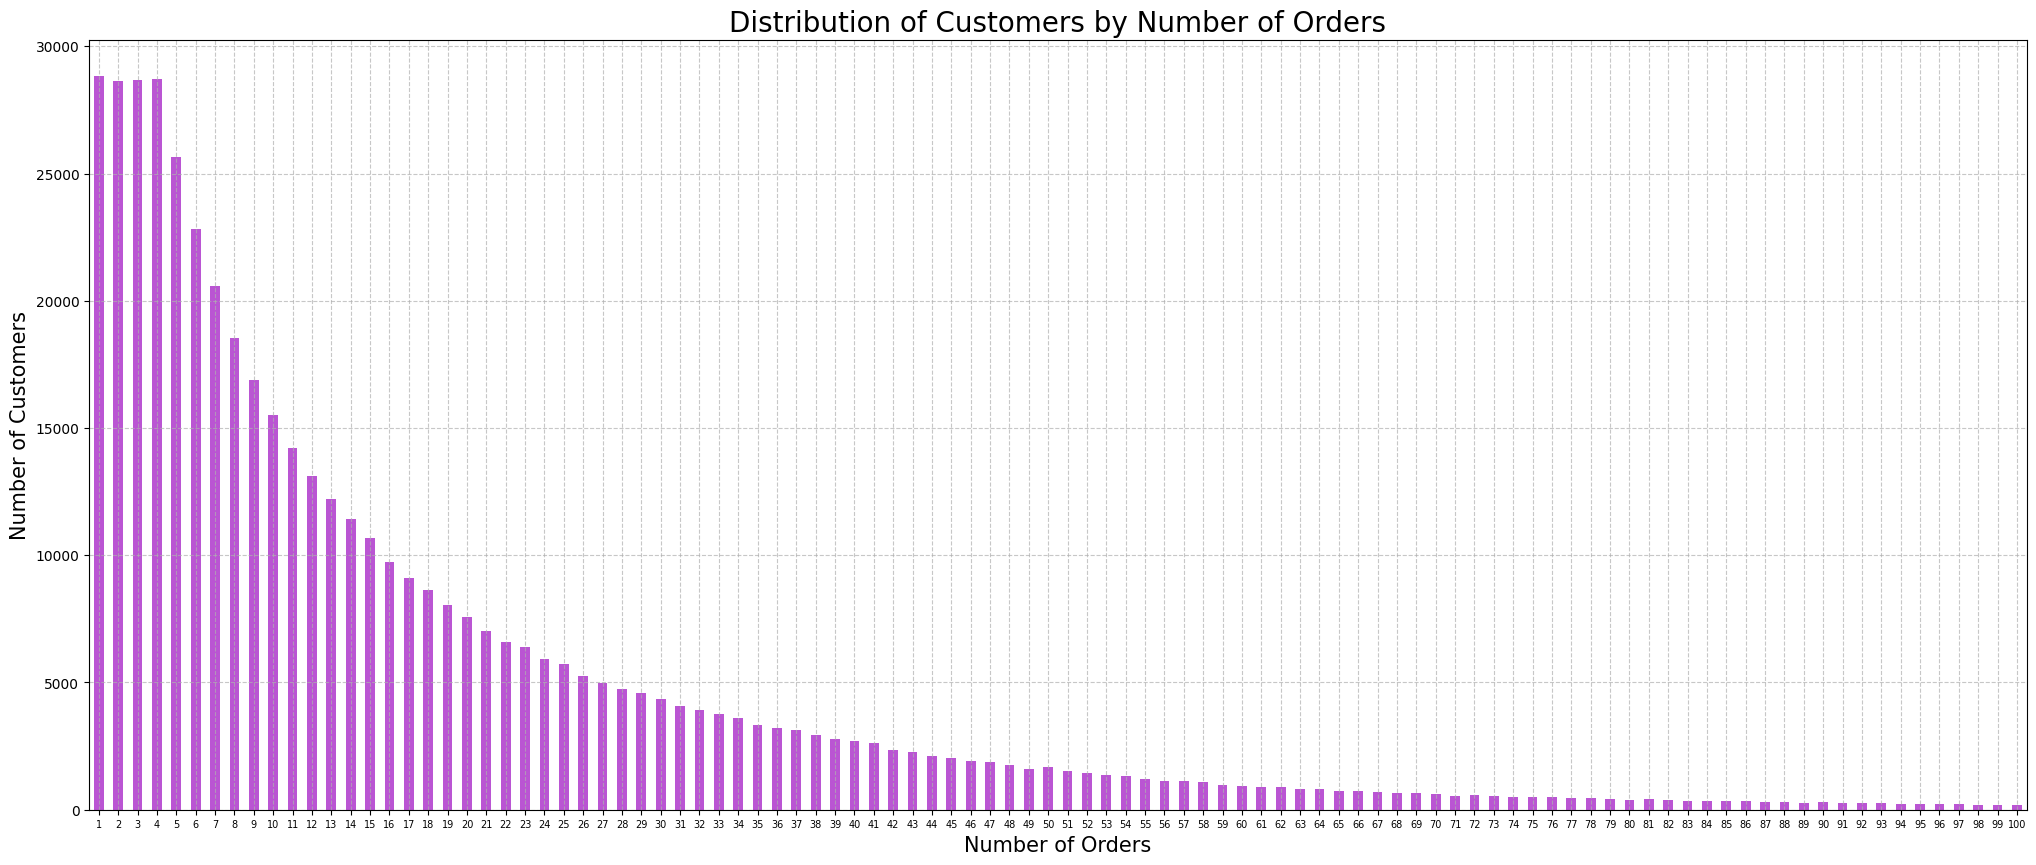

In [40]:
# Número de pedidos por clientes
user_order_num = instacart_orders['order_number'].value_counts().sort_index()
print("Mínima cantidad de clientes con un mismo número de órdenes:", user_order_num.min())
print("Máxima cantidad de clientes con un mismo número de órdenes:", user_order_num.max())
print()

# Gráfica de ordenes distribuídas por clientes
user_order_num.plot(kind='bar', color='mediumorchid', figsize=(25,10))
plt.title("Distribution of Customers by Number of Orders", fontsize=20)
plt.xlabel('Number of Orders', fontsize=15)
plt.ylabel("Number of Customers", fontsize=15)
plt.xticks(fontsize=7, rotation=0)
plt.yticks(fontsize=10, rotation=0)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()


**Para detectar cuántas órdenes han realizado los clientes en total, se agruparon por la columna `order_number` utilizando el método `value_counts()`. Esto reveló que la menor cantidad de clientes con un mismo número de órdenes es de 169, mientras que la mayor cantidad supera los 28,000.**

**La gráfica muestra que la mayor concentración de pedidos por cliente se encuentra entre 1 y 4 órdenes. A partir de ahí, se observa una notable disminución conforme aumenta el número de compras realizadas.**

**Este patrón sugiere un crecimiento reciente en la base de clientes de la plataforma: muchos usuarios nuevos realizan sus primeras compras, lo que genera un pico elevado en los primeros pedidos. Por otro lado, los clientes más antiguos, que compran de forma recurrente (semanal, quincenal o mensual), se van acumulando en los números de órdenes más altos.**

**Esta información puede aprovecharse para incentivar la suma de nuevos usuarios, por ejemplo, ofreciendo beneficios o promociones especiales en sus primeras compras.**

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

Mínimo de veces que se ha solicitado cualquier producto: 1
Máximo de veces que se ha solicitado cualquier producto: 66050

    product_id              product_name  order_count
0        24852                    BANANA        66050
1        13176    BAG OF ORGANIC BANANAS        53297
2        21137      ORGANIC STRAWBERRIES        37039
3        21903      ORGANIC BABY SPINACH        33971
4        47209      ORGANIC HASS AVOCADO        29773
5        47766           ORGANIC AVOCADO        24689
6        47626               LARGE LEMON        21495
7        16797              STRAWBERRIES        20018
8        26209                     LIMES        19690
9        27845        ORGANIC WHOLE MILK        19600
10       27966       ORGANIC RASPBERRIES        19197
11       22935      ORGANIC YELLOW ONION        15898
12       24964            ORGANIC GARLIC        15292
13       45007          ORGANIC ZUCCHINI        14584
14       39275       ORGANIC BLUEBERRIES        13879
15       4968

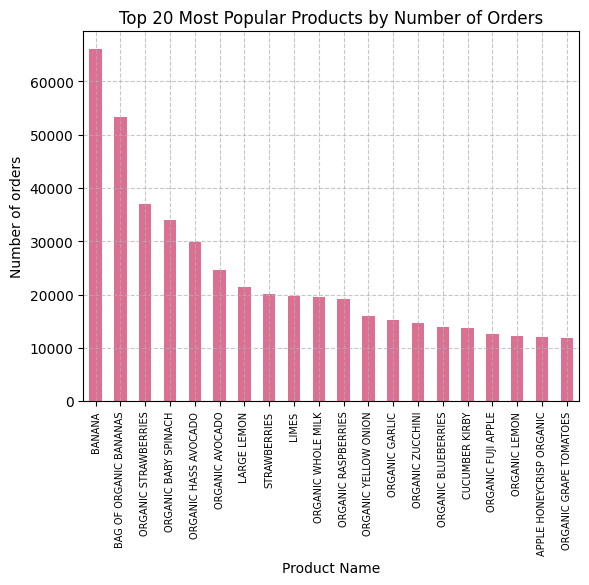

In [41]:
# ID de los productos y conteo total de productos
pop_prod_id = order_products['product_id'].value_counts().reset_index()
pop_prod_id.columns=['product_id', 'order_count']

print("Mínimo de veces que se ha solicitado cualquier producto:", pop_prod_id['order_count'].min())
print("Máximo de veces que se ha solicitado cualquier producto:", pop_prod_id['order_count'].max())
print()

# Nombres de los productos
pop_prod_names = products[['product_id', 'product_name']]

# Fusionar ambas tablas por ID de producto
pop_prod_merge = pop_prod_id.merge(pop_prod_names, on='product_id', how='left')

print(pop_prod_merge[['product_id', 'product_name', 'order_count']].head(20))
print()

# Gráfica categórica de órdenes por producto
pop_prod_merge.head(20).plot(kind='bar', x='product_name', y='order_count', color='palevioletred', legend=False)
plt.title('Top 20 Most Popular Products by Number of Orders')
plt.xlabel('Product Name')
plt.ylabel('Number of orders')
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()


**Para poder generar un DataFrame con los 20 productos más populares en la plataforma, se agrupó la tabla de `order_products` por la columna `product_id` mediante el método de `value_counts()`. Posteriormente con el método `merge()` se fusionó este DataFrame con la tabla de  `products`, que contenía los nombres de los productos, y finalmente se generó una gráfica con `plot()` para visualizar mejor los datos.**

**La gráfica muestra un pico importante en las ventas de plátanos, rebasando las 60,000 ventas, lo que convierte a este producto el más solicitado por los usuarios. Se observa que los 20 artículos más vendidos son principalmente frutas, vegetales y leche, lo que podría sugerir que los consumidores priorizan hábitos alimenticios saludables al seleccionar sus productos.**

**Esta información puede ser útil para diseñar estrategias de venta que promuevan productos menos solicitados mediante descuentos u ofertas con el fin de diversificar la demanda.**

# [C]

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

Mínimo de productos por pedido: 1
Máximo de productos por pedido: 127



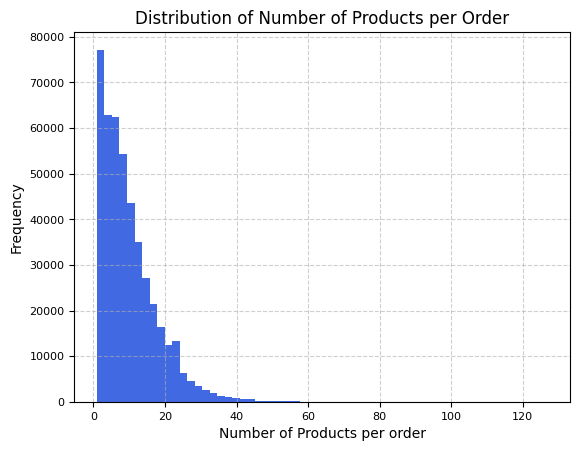

In [42]:
# Agrupar por órdenes para saber el número de pedidos en cada una
prod_num_by_order= order_products['order_id'].value_counts().reset_index()
prod_num_by_order.columns= ['order_id', 'products_count']
print("Mínimo de productos por pedido:", prod_num_by_order['products_count'].min())
print("Máximo de productos por pedido:", prod_num_by_order['products_count'].max())
print()

# Graficar la frecuencia de órdenes por numero de productos
prod_num_by_order['products_count'].plot(kind='hist', bins=60, color='royalblue')
plt.title('Distribution of Number of Products per Order')
plt.xlabel('Number of Products per order')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.show()


**La mayoría de los pedidos contienen entre 3 y 10 productos, con una alta concentración en esos rangos. A medida que aumenta la cantidad de productos en un pedido, la frecuencia disminuye considerablemente. Esto indica que los usuarios tienden a hacer compras moderadas en lugar de muy grandes.**

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

    product_id              product_name  product_count
0        24852                    BANANA          55763
1        13176    BAG OF ORGANIC BANANAS          44450
2        21137      ORGANIC STRAWBERRIES          28639
3        21903      ORGANIC BABY SPINACH          26233
4        47209      ORGANIC HASS AVOCADO          23629
5        47766           ORGANIC AVOCADO          18743
6        27845        ORGANIC WHOLE MILK          16251
7        47626               LARGE LEMON          15044
8        27966       ORGANIC RASPBERRIES          14748
9        16797              STRAWBERRIES          13945
10       26209                     LIMES          13327
11       22935      ORGANIC YELLOW ONION          11145
12       24964            ORGANIC GARLIC          10411
13       45007          ORGANIC ZUCCHINI          10076
14       49683            CUCUMBER KIRBY           9538
15       28204        ORGANIC FUJI APPLE           8989
16        8277  APPLE HONEYCRISP ORGANIC        

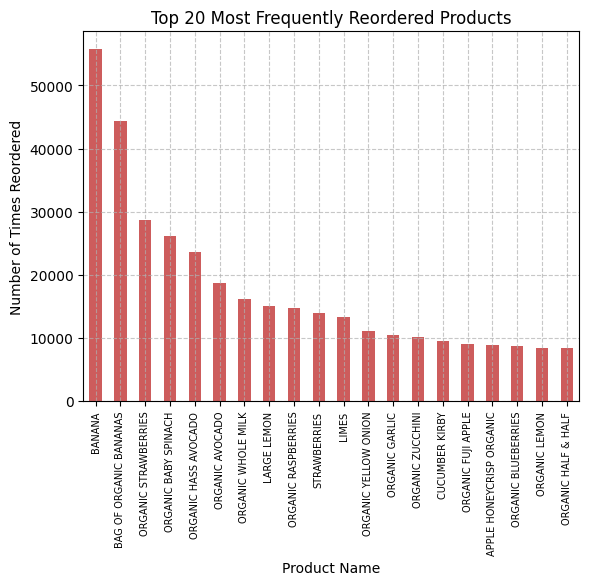

In [43]:
# Filtrar por artículos reordenados 
reordered_products= order_products[order_products['reordered']==1]['product_id'].value_counts().reset_index()
reordered_products.columns= ['product_id', 'product_count']

product_names = products[['product_id', 'product_name']]

# Fusionar tablas para obtener el nombre de los productos
reordered_products_merge = reordered_products.merge(product_names, on='product_id', how='left')
print(reordered_products_merge[['product_id', 'product_name', 'product_count']].head(20))
print()

# Graficar los productos más repetidos
reordered_products_merge.head(20).plot(kind='bar', x='product_name', y='product_count', legend=False, color='indianred')
plt.title('Top 20 Most Frequently Reordered Products')
plt.xlabel('Product Name')
plt.ylabel('Number of Times Reordered')
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()


**Para agrupar los productos que se vuelven a ordenar con mayor frecuencia, se utilizó un filtro mediante `value_counts()`. Posteriormente, para identificar los nombres de cada item, se fusionó con la tabla `product_names` mediante `merge()`, y finalmente se utilizó `plot()` para mostrar la gráfica.**

**En la gráfica se observa un pico principal: el plátano encabeza la lista, seguido por las bolsas de plátanos orgánicos y fresas orgánicas. A partir de ahí, una disminución notable en la frecuencia de reorden, destacando principalmente verduras, frutas y productos lácteos. Este patrón es similar al de los productos más populares en la plataforma, lo que sugiere que los consumidores frecuentes tienden a reordenar los mísmos artículos constantemente.**

**Esta información puede ser de utilidad para diseñar estrategias de abastecimiento de los productos más solicitados para minimizar el riesgo de desabasto, evitando así cancelaciones o sustituciones de producto.**

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

    product_id              product_name  reorder_count  reorder_proportion
0        24852                    BANANA        55763.0           84.425435
1        13176    BAG OF ORGANIC BANANAS        44450.0           83.400567
2        21137      ORGANIC STRAWBERRIES        28639.0           77.321202
3        21903      ORGANIC BABY SPINACH        26233.0           77.221748
4        47209      ORGANIC HASS AVOCADO        23629.0           79.363853
5        47766           ORGANIC AVOCADO        18743.0           75.916400
6        47626               LARGE LEMON        15044.0           69.988369
7        16797              STRAWBERRIES        13945.0           69.662304
8        26209                     LIMES        13327.0           67.684104
9        27845        ORGANIC WHOLE MILK        16251.0           82.913265
10       27966       ORGANIC RASPBERRIES        14748.0           76.824504
11       22935      ORGANIC YELLOW ONION        11145.0           70.103158
12       249

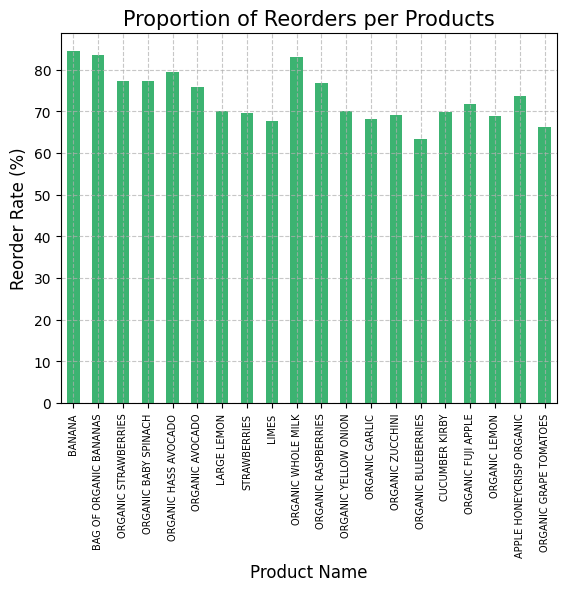

In [44]:
# Productos que se han pedido 
first_prod_order = order_products['product_id'].value_counts().reset_index()
first_prod_order.columns = ['product_id', 'total_count']

# Productos que se han reordenado
reorder_prod = order_products[order_products['reordered']==1]['product_id'].value_counts().reset_index()
reorder_prod.columns = ['product_id', 'reorder_count']

# Fusionar ambos DataFrames para tener un dataframe con el product_id, total_count y reorder_count
products_merge = first_prod_order.merge(reorder_prod, on='product_id', how='left')

#Fusionar con la tabla products para obtener los nombres de los productos
product_names = products[['product_id', 'product_name']]
reordered_product_names_merge = products_merge.merge(product_names, on='product_id', how='left')

# Proporcion de productos pedidos por primera vez y reordenados
reordered_product_names_merge['reorder_proportion'] = products_merge['reorder_count'] / products_merge['total_count'] * 100

print(reordered_product_names_merge[['product_id', 'product_name', 'reorder_count', 'reorder_proportion']].head(20))
print()

# Graficar la proporción
reordered_product_names_merge.head(20).plot(kind='bar', x='product_name', y='reorder_proportion', legend=False, color='mediumseagreen')
plt.title('Proportion of Reorders per Products',fontsize=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Reorder Rate (%)', fontsize=12)
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()
plt.show()


**Para obtener la proporción de productos que se vuelven a pedir, se fusionaron y filtraron las tablas `'order_product' y 'products'` mediante `value_counts y merge()`. Posteriormente, para calcular la proporción, se creó una nueva columna con el resultado de dividir `'reorder_count' entre 'total_count'`, iterando en cada fila del dataframe.**

**La gráfica muestra los 20 productos más vendidos y su proporción de reorden. Podemos observar que la probabilidad de que sean reordenados es muy alta en relación con sus pedidos totales, siendo los plátanos y la leche los productos con mayor fidelidad: ambos superan el 80%, seguidos por otros productos que tienen mas de 60% de probabilidad de volver a ser solicitados.**

**Esta información puede ser util para diseñar estrategias de marketing o promociones de recompra. Por ejemplo, se podrían ofrecer ciertos gramos gratis tras un número determinado de compras, o crear un sistema de recompensas basado en la frecuencia de reorden.**


### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

    user_id  total_ordered  total_reordered  reorder_proportion
0    103634            580            477.0           82.241379
1     33731            540            437.0           80.925926
2    137629            526            444.0           84.410646
3     23371            506            428.0           84.584980
4    164055            504            449.0           89.087302
5     59819            481            436.0           90.644491
6      4694            480            386.0           80.416667
7    186704            467            410.0           87.794433
8    166951            459            402.0           87.581699
9    201268            457            401.0           87.746171
10   129928            448            413.0           92.187500
11   193056            437            364.0           83.295195
12   176478            427            340.0           79.625293
13   100787            427            356.0           83.372365
14     6710            426            35

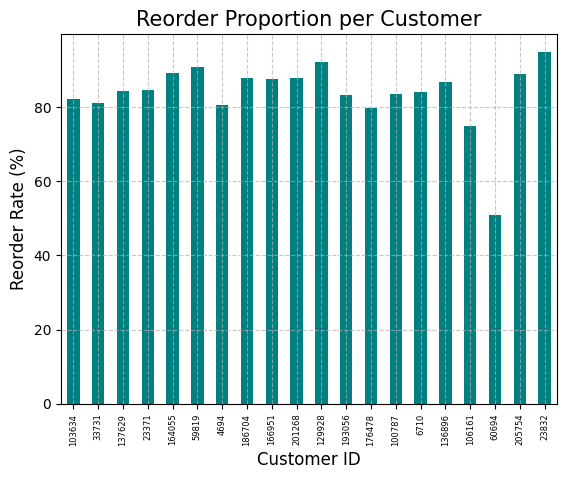

In [45]:
# Crear DataFrame que contenga 'user_id'
instacart_orders_user_id = instacart_orders[['order_id', 'user_id']]

# Crear DataFrame que contenga 'product_id', 'reordered'
order_products_reordered = order_products[['order_id', 'product_id', 'reordered']]

# Fusionar ambos DataFrames
customer_orders_data= instacart_orders_user_id.merge(order_products_reordered, on='order_id', how='left')

# Agrupar productos por cada usuario
total_products_by_customer = customer_orders_data['user_id'].value_counts().reset_index()
total_products_by_customer.columns= ['user_id', 'total_ordered']

# Agrupar productos reordenados por usuario
total_products_reordered_by_customer = customer_orders_data[customer_orders_data['reordered']==1]['user_id'].value_counts().reset_index()
total_products_reordered_by_customer.columns= ['user_id', 'total_reordered']

# Fusionar
customer_merge= total_products_by_customer.merge(total_products_reordered_by_customer, on='user_id', how='left')

# Identificar la proporción de productos reordenados
customer_merge['reorder_proportion'] = customer_merge['total_reordered'] / customer_merge['total_ordered'] * 100

print(customer_merge.head(20))
print()

# Graficar la proporción
customer_merge.head(20).plot(kind='bar', x='user_id', y='reorder_proportion', legend=False, color='teal')
plt.title('Reorder Proportion per Customer',fontsize=15)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Reorder Rate (%)', fontsize=12)
plt.xticks(fontsize=6)
plt.yticks(fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()
plt.show()


**Para poder tener la proporción de artíclos reordenados por cliente, fue necesario fusionar y filtr las tablas `instacart_order` y `order_productos` mediante `value_counts() y merge()`. Posteriormente se creó una nueva columna llamada `proportion_reordered` que contiene el resultado de dividir  `total_reordered entre total_ordered`. Finalmente, para una mejor lectura de datos se realizó una gráfica mediante `plot`.**

**La gráfica muestra que la gran mayoría de los clientes supera el 80% de proporción de reorden, lo cual que cada usuario tiende a realizar prácticamente el mismo pedido en cada orden. Este comportamiento podría reflejar hábitos de consumo regulares, donde se reponen artículos esenciales en cada pedido, acompañados ocasionalmente de productos nuevos o esporádicos.**

**Esta información puede aprovecharse para implementar opciones predeterminadas o carritos inteligentes en la plataforma, que incluyan automáticamente los artículos más frecuentes de cada cliente para mejorar la experiencia del usuario.**

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

    product_id                 product_name  total_first_item_add_to_cart
0        24852                       BANANA                         15562
1        13176       BAG OF ORGANIC BANANAS                         11026
2        27845           ORGANIC WHOLE MILK                          4363
3        21137         ORGANIC STRAWBERRIES                          3946
4        47209         ORGANIC HASS AVOCADO                          3390
5        21903         ORGANIC BABY SPINACH                          3336
6        47766              ORGANIC AVOCADO                          3044
7        19660                 SPRING WATER                          2336
8        16797                 STRAWBERRIES                          2308
9        27966          ORGANIC RASPBERRIES                          2024
10       44632   SPARKLING WATER GRAPEFRUIT                          1914
11       49235          ORGANIC HALF & HALF                          1797
12       47626                  LARGE 

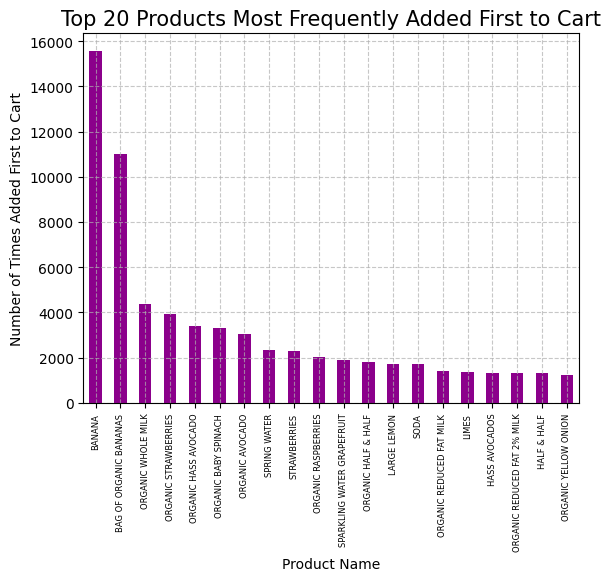

In [46]:
# Filtrar primeros productos agregados al carrito
first_added_product= order_products[order_products['add_to_cart_order']==1]['product_id'].value_counts().reset_index()
first_added_product.columns = ['product_id', 'total_first_item_add_to_cart']

# Fusionar con tabla de nombres
product_names = products[['product_id', 'product_name']]
name_first_added_product = first_added_product.merge(product_names, on='product_id', how='left')

print(name_first_added_product[['product_id', 'product_name', 'total_first_item_add_to_cart']].head(20))
print()

# Graficar
name_first_added_product.head(20).plot(kind='bar', x='product_name', y='total_first_item_add_to_cart', legend=False, color='darkmagenta')
plt.title('Top 20 Products Most Frequently Added First to Cart',fontsize=15)
plt.xlabel('Product Name', fontsize=10)
plt.ylabel('Number of Times Added First to Cart', fontsize=10)
plt.xticks(fontsize=6)
plt.yticks(fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()
plt.show()


**Para obtener cuáles son los 20 productos que más frecuentemente se agregan primero al carrito, se aplicó un filtro y una fusión entre las tablas `order_products y products` mediante `value_counts()` y `merge()`. Posteriormente, se utilizó `plot()` para visualizar los resultados.**

**La gráfica muestra que el producto más comúnmente agregado primero es el plátano, seguido de productos lácteos, frutas y verduras. Este patrón sugiere la alta prioridad que los usuarios le dan a ciertos productos básicos, especialmente saludables, al iniciar sus compras. Es consistente con los resultados de otras gráficas, donde el plátano también aparece como uno de los productos más vendidos y reordenados, lo que refuerza su relevancia en los hábitos de consumo.**

**Esta información puede ser útil para mejorar la experiencia del usuario en la plataforma, por ejemplo, sugiriendo automáticamente al principio los productos más frecuentamente agregados por cada cliente al inicio del proceso de compra.**

### Conclusion general del proyecto:

**Este análsis tuvo como objetivo principal comprender los hábitos de consumo de los usuarios de Instacart, mediante el estudio de sus patrones de compra: desde los horarios y días preferidos para hacer pedidos, hasta los productos más recurrentes, la dinámica de reordenamiento y el comportamiento al agregar productos al carrito.**

**A través de las gráficas y tablas generadas, se identificó que la mayoría de los usuarios realiza sus compras los fines de semana y también al comienzo del mes, especialmente entre las 10:00 y 16:00 horas. Durante este periodo, los productos más presentes en los carritos son frutas (particularmente plátanos), verduras y productos lácteos. Este comportamiento sugiere que los usuarios planifican sus compras con antelación, priorizando alimentos básicos y saludables para abastecerse semanalmente.**

**También fue posible observar una alta proporción de reordednamiento tanto por producto como por cliente, lo que indica que muchos usuarios tienden a adquirir los mismos artículos en sus pedidos, reflejando rutinas alimenticias constantes. Además, el hecho de que ciertos productos, como el plátano, se agreguen primero al carrito refuerza que son esenciales en las compras.**

**El análisis también permitió conocer mejor el comportamiento general de los usuarios. La mayoría realiza productos que incluyen entre 3 y 10 productos aproximadamente. En cuanto al tiempo entre compras, se observó que existen picos recurrentes a los 7 y 30 días, lo que sugiere ciclos de compra semanales y mensuales. Por otro lado, al comparar los hábitos de compra entre miércoles a sábado, se identificó un patrón similar en horarios, aunque los sábados reflejan una mayor actividad.**

**Estos hallazgos pueden ser de utilidad para la toma de decisiones dentro de la plataforma, como el diseño de promociones personalizadas, beneficios para clientes frecuentes, la mejora de experiencia del usuario (por ejemplo, implementando recomendaciones automáticas), la optimización de horarios de entrega y el manjeo eficiente del inventario.**

**En resumen, los datos muestran que Instacart es una herramienta clave para los usuarios en su vida diaria, no solo para resolver compras esporádicas, sino como apoyo constante en la organización de su alimentación semanal, con un fuerte enfoque en productos saludables.**
